### Imports

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)

from scipy.stats import (
    pearsonr,
    spearmanr,
    linregress
)

import matplotlib.pyplot as plt

In [2]:
os.makedirs(
    "../outputs/plots/eeg_cognition_combined",
    exist_ok=True
)

### Load Dataset

In [3]:

df = pd.read_csv("../data/processed/merged_dataset.csv")

print(df.shape)
df.head()

(100, 1096)


,file_id,filepath,age,sex_x,brain_health_score,total_cognition_score,fluid_cognition_score,crystallized_cognition_score,lhl_1,lhl_2,...,BT2.h.7,SGOT2.h.8,SGPT,Family _History,Medical_History,Barthel_scale,MRS_scale,NIHSS_scale,AHI_1_B,subject_id
0,SN1,sleep_data/SN1.edf,65.0,1,-0.27464,-0.01407,-0.10628,0.08692,0.022346,-0.994057,...,1.14,29.8,25.7,NaN,NaN,100.0,0.0,0.0,50.8,SN1
1,SN2,sleep_data/SN2.edf,60.0,1,-0.36531,0.06125,-0.09295,0.30379,0.152037,-0.997863,...,NaN,30.1,26.8,NaN,NaN,100.0,0.0,0.0,6.5,SN2
2,SN3,sleep_data/SN3.edf,49.0,1,0.24275,0.49118,0.45108,0.23969,0.210161,-0.920484,...,NaN,NaN,NaN,NaN,NaN,100.0,0.0,0.0,41.1,SN3
3,SN4,sleep_data/SN4.edf,47.0,1,0.16931,0.49646,0.48187,0.24427,0.123935,-0.969290,...,0.78,23,25.0,1,NaN,100.0,0.0,0.0,39.1,SN4
4,SN5,sleep_data/SN5.edf,39.0,1,0.00631,0.31138,0.31247,-0.02889,0.179273,-0.829033,...,0.70,30,40.0,NaN,NaN,100.0,0.0,0.0,1.9,SN5


### ALL Features

In [4]:
eeg_features = [
    col for col in df.columns
    if col.startswith("lhl_")
]

cognition_features = [
    "brain_health_score",
    "total_cognition_score",
    "fluid_cognition_score",
    "crystallized_cognition_score"
]

print(len(eeg_features))

1024


In [5]:
combined_features = (
    eeg_features +
    cognition_features
)

print(
    "Total Features:",
    len(combined_features)
)

Total Features: 1028


In [6]:
target = "AHI_1_B"

data = df[
    combined_features + [target]
].dropna()

X = data[combined_features]

y = data[target]

print(X.shape)
print(y.shape)

(100, 1028)
(100,)


## Linear Regression LOSO

In [7]:
loo = LeaveOneOut()

linear_actual = []
linear_predicted = []

model = LinearRegression()

for train_idx, test_idx in loo.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    pred = np.clip(pred, 0, None)

    linear_actual.append(y_test.values[0])
    linear_predicted.append(pred[0])

print("Linear Done")

Linear Done


### Linear Metrics 

In [8]:
linear_mae = mean_absolute_error(
    linear_actual,
    linear_predicted
)

linear_medae = median_absolute_error(
    linear_actual,
    linear_predicted
)

linear_rmse = np.sqrt(
    mean_squared_error(
        linear_actual,
        linear_predicted
    )
)

linear_r2 = r2_score(
    linear_actual,
    linear_predicted
)

linear_pearson, _ = pearsonr(
    linear_actual,
    linear_predicted
)

linear_spearman, _ = spearmanr(
    linear_actual,
    linear_predicted
)

### Linear Regression Plot

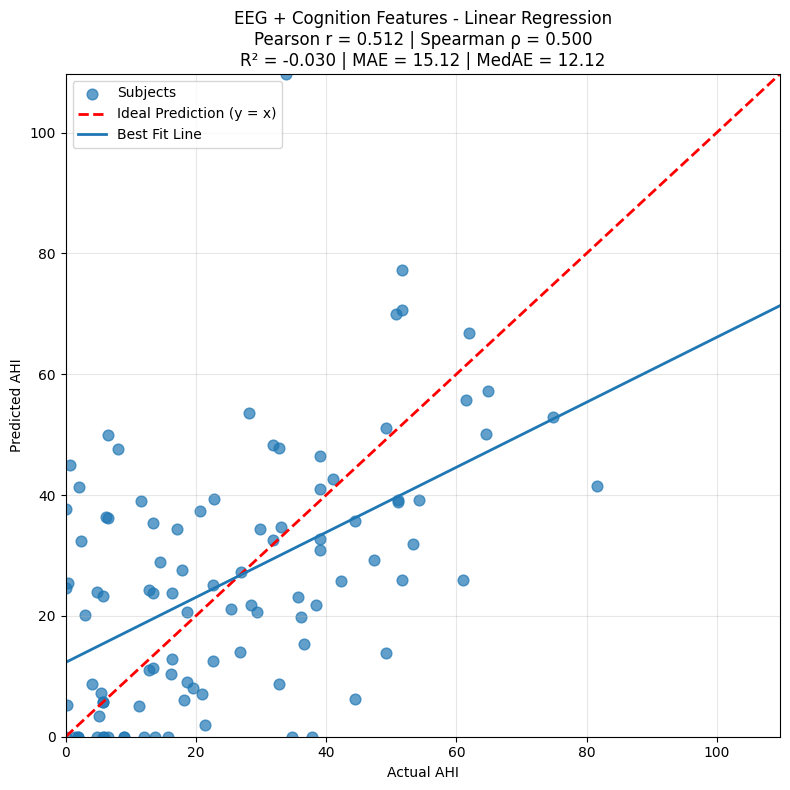

In [9]:
fit = linregress(
    linear_actual,
    linear_predicted
)

slope = fit.slope
intercept = fit.intercept

max_val = max(
    max(linear_actual),
    max(linear_predicted)
)

x_line = np.linspace(
    0,
    max_val,
    500
)

y_fit = slope * x_line + intercept

plt.figure(figsize=(8, 8))

plt.scatter(
    linear_actual,
    linear_predicted,
    s=60,
    alpha=0.7,
    label="Subjects"
)

plt.plot(
    [0, max_val],
    [0, max_val],
    "r--",
    linewidth=2,
    label="Ideal Prediction (y = x)"
)

plt.plot(
    x_line,
    y_fit,
    linewidth=2,
    label="Best Fit Line"
)

plt.xlabel("Actual AHI")
plt.ylabel("Predicted AHI")

plt.title(
    f"EEG + Cognition Features - Linear Regression\n"
    f"Pearson r = {linear_pearson:.3f} | "
    f"Spearman ρ = {linear_spearman:.3f}\n"
    f"R² = {linear_r2:.3f} | "
    f"MAE = {linear_mae:.2f} | "
    f"MedAE = {linear_medae:.2f}"
)

plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/eeg_cognition_combined/linear_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Ridge Regression LOSO

In [10]:
ridge_actual = []
ridge_predicted = []

model = Ridge(alpha=0.1)

for train_idx, test_idx in loo.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    pred = np.clip(pred, 0, None)

    ridge_actual.append(y_test.values[0])
    ridge_predicted.append(pred[0])

print("Ridge Done")

Ridge Done


### Ridge Metrics

In [11]:
ridge_mae = mean_absolute_error(
    ridge_actual,
    ridge_predicted
)

ridge_medae = median_absolute_error(
    ridge_actual,
    ridge_predicted
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        ridge_actual,
        ridge_predicted
    )
)

ridge_r2 = r2_score(
    ridge_actual,
    ridge_predicted
)

ridge_pearson, _ = pearsonr(
    ridge_actual,
    ridge_predicted
)

ridge_spearman, _ = spearmanr(
    ridge_actual,
    ridge_predicted
)

### Ridge Regression Plot

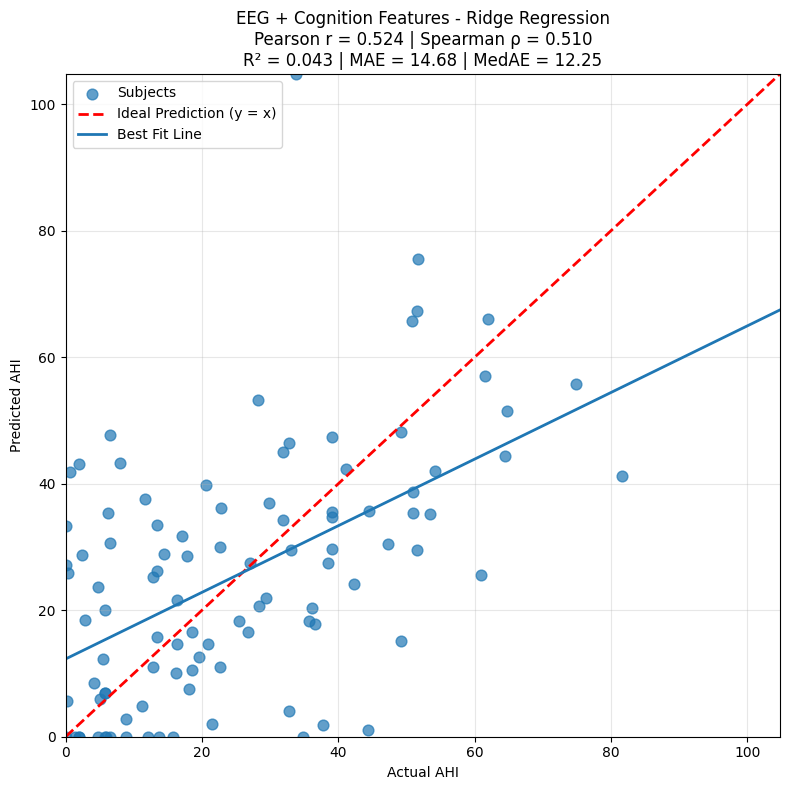

In [12]:
fit = linregress(
    ridge_actual,
    ridge_predicted
)

slope = fit.slope
intercept = fit.intercept

max_val = max(
    max(ridge_actual),
    max(ridge_predicted)
)

x_line = np.linspace(0, max_val, 500)
y_fit = slope * x_line + intercept

plt.figure(figsize=(8, 8))

plt.scatter(
    ridge_actual,
    ridge_predicted,
    s=60,
    alpha=0.7,
    label="Subjects"
)

plt.plot(
    [0, max_val],
    [0, max_val],
    "r--",
    linewidth=2,
    label="Ideal Prediction (y = x)"
)

plt.plot(
    x_line,
    y_fit,
    linewidth=2,
    label="Best Fit Line"
)

plt.xlabel("Actual AHI")
plt.ylabel("Predicted AHI")

plt.title(
    f"EEG + Cognition Features - Ridge Regression\n"
    f"Pearson r = {ridge_pearson:.3f} | "
    f"Spearman ρ = {ridge_spearman:.3f}\n"
    f"R² = {ridge_r2:.3f} | "
    f"MAE = {ridge_mae:.2f} | "
    f"MedAE = {ridge_medae:.2f}"
)

plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/eeg_cognition_combined/ridge_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Lasso Regression LOSO

In [13]:
lasso_actual = []
lasso_predicted = []

model = Lasso(
    alpha=0.1,
    max_iter=10000
)

for train_idx, test_idx in loo.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    pred = np.clip(pred, 0, None)

    lasso_actual.append(y_test.values[0])
    lasso_predicted.append(pred[0])

print("Lasso Done")

Lasso Done


### Lasso Metrics

In [14]:
lasso_mae = mean_absolute_error(
    lasso_actual,
    lasso_predicted
)

lasso_medae = median_absolute_error(
    lasso_actual,
    lasso_predicted
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        lasso_actual,
        lasso_predicted
    )
)

lasso_r2 = r2_score(
    lasso_actual,
    lasso_predicted
)

lasso_pearson, _ = pearsonr(
    lasso_actual,
    lasso_predicted
)

lasso_spearman, _ = spearmanr(
    lasso_actual,
    lasso_predicted
)

### Lasso Regression Plot

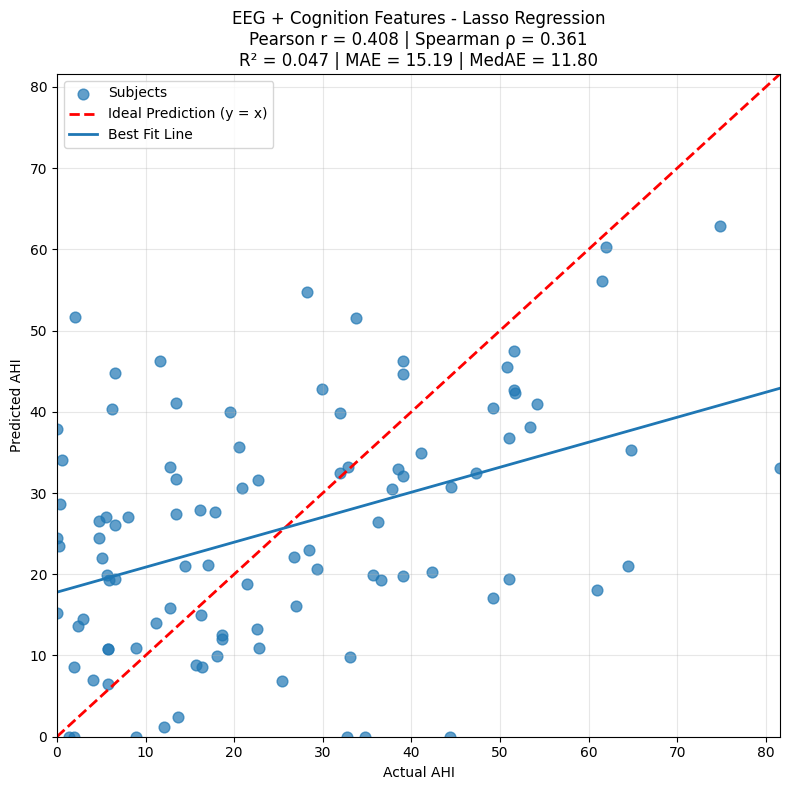

In [15]:
fit = linregress(
    lasso_actual,
    lasso_predicted
)

slope = fit.slope
intercept = fit.intercept

max_val = max(
    max(lasso_actual),
    max(lasso_predicted)
)

x_line = np.linspace(0, max_val, 500)
y_fit = slope * x_line + intercept

plt.figure(figsize=(8, 8))

plt.scatter(
    lasso_actual,
    lasso_predicted,
    s=60,
    alpha=0.7,
    label="Subjects"
)

plt.plot(
    [0, max_val],
    [0, max_val],
    "r--",
    linewidth=2,
    label="Ideal Prediction (y = x)"
)

plt.plot(
    x_line,
    y_fit,
    linewidth=2,
    label="Best Fit Line"
)

plt.xlabel("Actual AHI")
plt.ylabel("Predicted AHI")

plt.title(
    f"EEG + Cognition Features - Lasso Regression\n"
    f"Pearson r = {lasso_pearson:.3f} | "
    f"Spearman ρ = {lasso_spearman:.3f}\n"
    f"R² = {lasso_r2:.3f} | "
    f"MAE = {lasso_mae:.2f} | "
    f"MedAE = {lasso_medae:.2f}"
)

plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/eeg_cognition_combined/lasso_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
predictions_df = pd.DataFrame({
    "Actual_AHI": linear_actual,
    "Linear_Predicted": linear_predicted,
    "Ridge_Predicted": ridge_predicted,
    "Lasso_Predicted": lasso_predicted
})

predictions_df.to_csv(
    "../outputs/predictions/eeg_cognition_predictions.csv",
    index=False
)

predictions_df.head()

,Actual_AHI,Linear_Predicted,Ridge_Predicted,Lasso_Predicted
0,50.8,69.931223,65.705496,45.551579
1,6.5,0.000000,0.000000,19.393295
2,41.1,42.670217,42.322184,34.892377
3,39.1,46.451929,47.388041,46.270849
4,1.9,0.000000,0.000000,0.000000


In [17]:
print(X.shape)
print(y.shape)

(100, 1028)
(100,)


### Metrics

In [18]:
metrics_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae
    ],
    "MedAE": [
        linear_medae,
        ridge_medae,
        lasso_medae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        lasso_r2
    ],
    "Pearson_r": [
        linear_pearson,
        ridge_pearson,
        lasso_pearson
    ],
    "Spearman_rho": [
        linear_spearman,
        ridge_spearman,
        lasso_spearman
    ]
})

metrics_df = metrics_df.round(4)

metrics_df.to_csv(
    "../outputs/metrics/eeg_cognition_comparison_metrics.csv",
    index=False
)

metrics_df

,Model,MAE,MedAE,RMSE,R2,Pearson_r,Spearman_rho
0,Linear Regression,15.1157,12.1174,19.9656,-0.0304,0.5118,0.4997
1,Ridge Regression,14.6850,12.2548,19.2414,0.0429,0.5240,0.5103
2,Lasso Regression,15.1894,11.7966,19.1983,0.0472,0.4083,0.3613
